# Detecting Nmap Behavior with Bro HTTP Logs, using ParseZeekLogs

This is the hunt from [*Threat Hunting with Python: Prologue and Basic HTTP Hunting*](../docs/2017-09-threat-hunting-with-python-prologue.md) and [*Part 2: Detecting Nmap Behavior with Bro HTTP Logs*](../docs/2017-11-threat-hunting-with-python-part-2-nmap-bro-http.md), redone with today's tools. The two original notebooks in this folder split each line of `http.log` on tabs and count values by hand; they still run and are kept as written. Here the same questions are answered with [ParseZeekLogs](https://github.com/dgunter/ParseZeekLogs), which reads Bro/Zeek logs into typed records, and pandas.

The log is one day of HTTP traffic from the 2015 4SICS conference lab network.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from parsezeeklogs import ZeekLog

plt.style.use("ggplot")
%matplotlib inline

## Load the log

`ZeekLog` reads the `#fields` and `#types` header, so every column already has the right type: `ts` is a float, ports and status codes are integers, and unset fields (`-`) are `None`. No index arithmetic, no comment-line filtering.

In [2]:
with ZeekLog("http.log") as log:
    df = pd.DataFrame(log)

df["ts"] = pd.to_datetime(df["ts"], unit="s", utc=True)
print(f"{len(df)} records, {df['ts'].min()} to {df['ts'].max()}")
df[["ts", "id.orig_h", "id.resp_h", "method", "host", "uri", "user_agent", "status_code"]].head()

5758 records, 2015-10-21 10:09:20.958110094+00:00 to 2015-10-21 16:54:37.424937010+00:00


,ts,id.orig_h,id.resp_h,method,host,uri,user_agent,status_code
0,2015-10-21 10:09:20.958470106+00:00,192.168.2.64,192.168.88.51,GET,NaN,/,NaN,200.0
1,2015-10-21 10:09:20.959613085+00:00,192.168.2.64,192.168.88.60,GET,NaN,/,NaN,302.0
2,2015-10-21 10:09:20.958110094+00:00,192.168.2.64,192.168.88.49,GET,NaN,/,NaN,200.0
3,2015-10-21 10:09:20.962326050+00:00,192.168.2.64,192.168.88.25,GET,NaN,/,NaN,401.0
4,2015-10-21 10:09:21.005907059+00:00,192.168.2.64,192.168.88.49,OPTIONS,NaN,/,NaN,501.0


## Hypothesis 1: scanners leave fingerprints in the user agent and URI

Stacking is counting values and looking at the outliers. Seven user agents cover the whole day, and one of them names the tool.

In [3]:
df["user_agent"].fillna("(unset)").value_counts()

user_agent
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/46.0.2490.64 Safari/537.36    5045
Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:39.0) Gecko/20100101 Firefox/39.0                                 327
Mozilla/5.0 (compatible; Nmap Scripting Engine; http://nmap.org/book/nse.html)                               171
(unset)                                                                                                      103
Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:41.0) Gecko/20100101 Firefox/41.0                                  99
Mozilla/5.0 (X11; Ubuntu; Linux i686; rv:28.0) Gecko/20100101 Firefox/28.0                                    12
Wget/1.16.1 (linux-gnu)                                                                                        1
Name: count, dtype: int64

In [4]:
# Stack URIs with query strings removed
df["uri"].str.split("?").str[0].value_counts().head(20)

uri
/                            187
/favicon.ico                  81
/stserial.asp                 80
/auth/auth.asp                23
/phoenix_fl.js                20
/phoenix_fl.css               20
/img/device_s.gif             20
/img/pxclogo.gif              20
/img/sel.gif                  16
/auth/topplan_auth.asp        15
/auth/name_auth.asp           13
/auth/led_auth.asp            13
/auth/accountpassword.asp     13
/auth/logo1.gif               13
/auth/logo3.gif               13
/auth/md5.js                  13
/auth/loginin.gif             13
/robots.txt                   11
/.git/HEAD                    11
/home.asp                     10
Name: count, dtype: int64

## Search: who did the Nmap Scripting Engine talk to?

The original notebook builds a nested dictionary of client, server and timestamp; a `groupby` does the same in one line.

In [5]:
NMAP_UA = "Mozilla/5.0 (compatible; Nmap Scripting Engine; http://nmap.org/book/nse.html)"
nmap = df[df["user_agent"] == NMAP_UA]
requests_per_pair = (
    nmap.groupby(["id.orig_h", "id.resp_h"]).size().rename("requests").reset_index()
)
requests_per_pair.sort_values(["id.orig_h", "requests"], ascending=[True, False])

,id.orig_h,id.resp_h,requests
0,192.168.2.42,192.168.88.115,18
6,192.168.2.64,192.168.88.51,39
4,192.168.2.64,192.168.88.25,18
7,192.168.2.64,192.168.88.60,17
9,192.168.2.64,192.168.88.95,16
2,192.168.2.64,192.168.88.115,15
8,192.168.2.64,192.168.88.61,15
3,192.168.2.64,192.168.88.20,14
5,192.168.2.64,192.168.88.49,14
1,192.168.2.64,192.168.88.100,5


Two clients on the 192.168.2.0/24 network scanned nine hosts on 192.168.88.0/24. Every record involving those client/server pairs is worth a look, not just the ones with the Nmap user agent, since a scan is usually followed by something else.

In [6]:
pairs = set(map(tuple, requests_per_pair[["id.orig_h", "id.resp_h"]].to_numpy()))
suspicious = df[[(c, s) in pairs for c, s in zip(df["id.orig_h"], df["id.resp_h"], strict=True)]]
print(f"{len(suspicious)} records between scanning clients and scanned servers")
suspicious["user_agent"].fillna("(unset)").value_counts()

299 records between scanning clients and scanned servers


user_agent
Mozilla/5.0 (compatible; Nmap Scripting Engine; http://nmap.org/book/nse.html)                              171
(unset)                                                                                                      80
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/46.0.2490.64 Safari/537.36     48
Name: count, dtype: int64

In [7]:
# Same CSV the original notebook produced, for people who want to pivot in a spreadsheet
suspicious.to_csv("suspicious_http_records_parsezeeklogs.csv", index=False)

## Hypothesis 2: scanning shows up as bursts in time

Part 2 of the series looks at the same log as a time series. Requests per minute per user agent make the scan window obvious once the high-volume browser is removed.

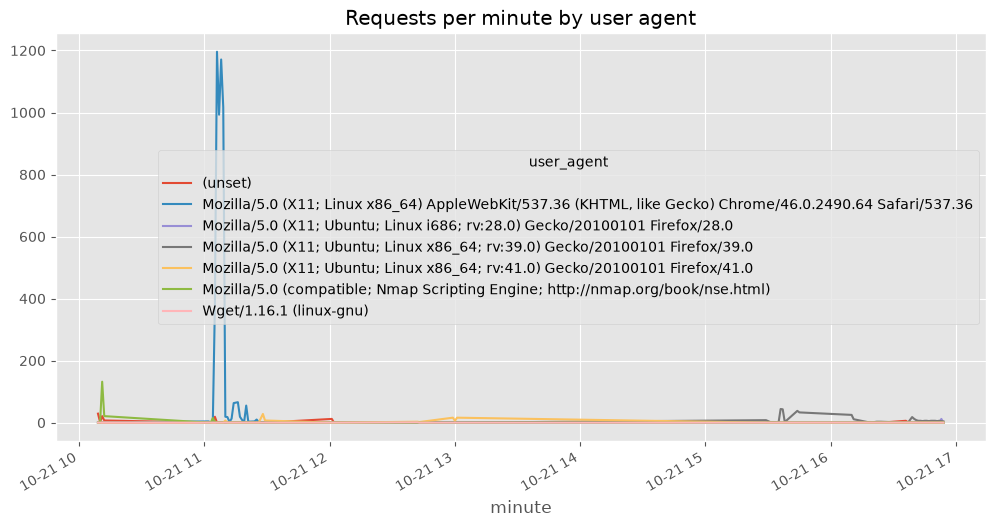

In [8]:
per_minute = (
    df.assign(minute=df["ts"].dt.floor("min"), user_agent=df["user_agent"].fillna("(unset)"))
    .groupby(["minute", "user_agent"])
    .size()
    .unstack(fill_value=0)
)
per_minute.plot(figsize=(12, 6), title="Requests per minute by user agent");

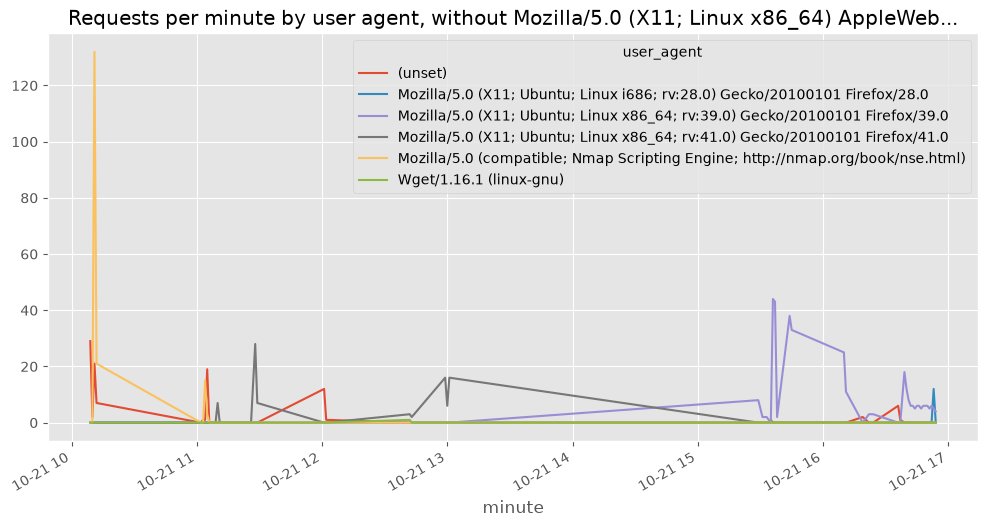

In [9]:
# Drop the busiest user agent so the others are visible (when there is more than one)
busiest = per_minute.sum().idxmax()
rest = per_minute.drop(columns=busiest)
if not rest.empty:
    ax = rest.plot(figsize=(12, 6))
    ax.set_title(f"Requests per minute by user agent, without {busiest[:40]}...")

## Status codes

A scanner probing paths that do not exist produces error responses in bulk. The distribution and the per-minute view both show it.

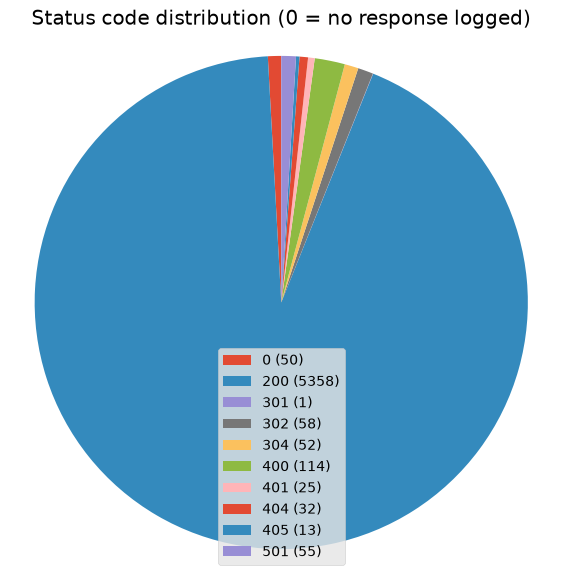

In [10]:
status = df["status_code"].fillna(0).astype(int).value_counts().sort_index()
labels = [f"{code} ({count})" for code, count in status.items()]
fig, ax = plt.subplots(figsize=(7, 7))
patches, _ = ax.pie(status, startangle=90)
ax.legend(patches, labels, loc="best")
ax.set_title("Status code distribution (0 = no response logged)")
ax.axis("equal");

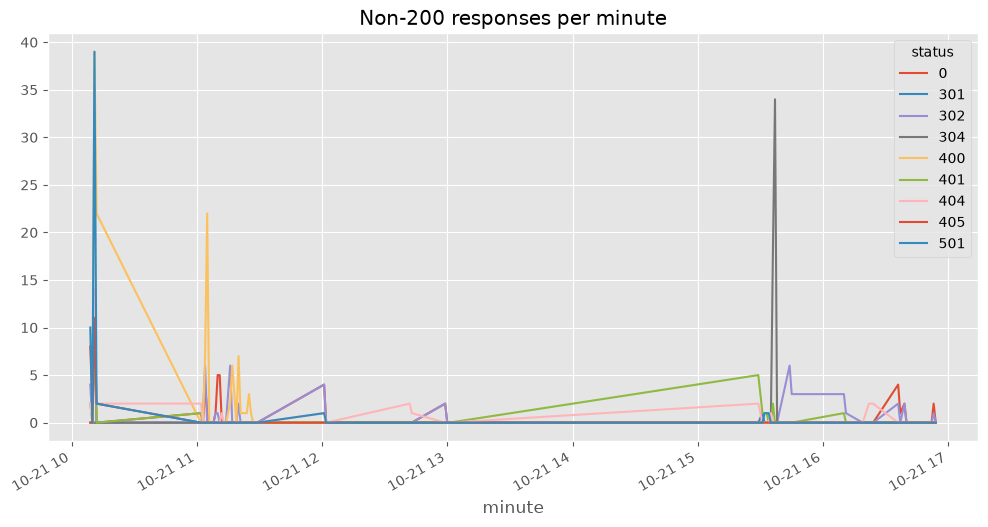

In [11]:
status_per_minute = (
    df.assign(minute=df["ts"].dt.floor("min"), status=df["status_code"].fillna(0).astype(int))
    .groupby(["minute", "status"])
    .size()
    .unstack(fill_value=0)
)
status_per_minute.drop(columns=200, errors="ignore").plot(
    figsize=(12, 6), title="Non-200 responses per minute"
);

## What changed since 2017

- The log is parsed by a library that understands the Zeek format, so the notebook is about the hunt rather than about tab positions.
- Timestamps are real datetimes; the original stringified them minute by minute to group them.
- `groupby` and `value_counts` replace the hand-rolled dictionaries.
- The same library can also emit these records in Elastic Common Schema for Elasticsearch or Kibana, if the hunt outgrows a notebook.